# Overview
This notebook is to test different APIs. Most noteably:
- newsapi.org
- newsapi.ai

---
## NewsAPI.org
We get a free API key allowing us to scrape up to 100 articles for a month worth of historical data. 

We will focus on energy and only reputable sources. This first code is to test to pull data and quickly analyse it.

In [28]:
import os
from dotenv import load_dotenv
from newsapi import NewsApiClient
import pandas as pd

# Load environment variables from .env file
load_dotenv()

# Get API key from environment
api_key = os.getenv('NEWSAPIORG_KEY')

# Initialize the NewsAPI client
newsapi = NewsApiClient(api_key=api_key)

# Define specific sources
sources = 'associated-press,bloomberg,cnn,reuters,the-huffington-post,the-wall-street-journal,the-washington-post'

# Search for articles mentioning energy, oil, or gas
print("=== Fetching Articles (energy, oil, gas) ===")
all_articles = newsapi.get_everything(
    q='oil OR electricity OR gas OR coal',
    sources=sources,
    language='en',
    sort_by='publishedAt',
    page_size=100
)

print(f"Total results: {all_articles['totalResults']}")
print(f"Number of articles returned: {len(all_articles['articles'])}")

# Convert to DataFrame
print("\n\n=== DataFrame Conversion ===")
if len(all_articles['articles']) > 0:
    df_articles = pd.DataFrame(all_articles['articles'])
    print(f"DataFrame shape: {df_articles.shape}")
    print(f"Columns: {df_articles.columns.tolist()}")
    
    # Flatten the 'source' column (it's a nested dict)
    df_articles['source_id'] = df_articles['source'].apply(lambda x: x['id'] if x else None)
    df_articles['source_name'] = df_articles['source'].apply(lambda x: x['name'] if x else None)
else:
    print("No articles returned!")


=== Fetching Articles (energy, oil, gas) ===
Total results: 140
Number of articles returned: 100


=== DataFrame Conversion ===
DataFrame shape: (100, 8)
Columns: ['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']


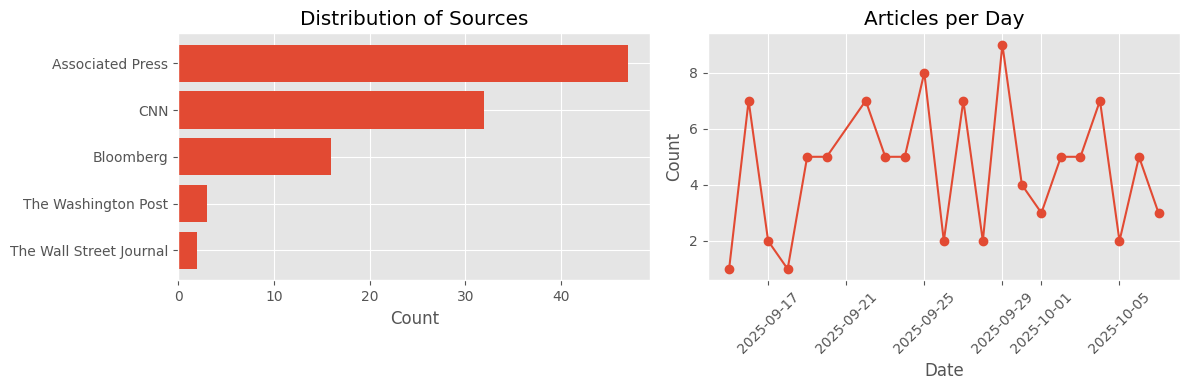

In [29]:
import matplotlib.pyplot as plt

# Set style
plt.style.use('ggplot')

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Distribution of sources
source_counts = df_articles['source_name'].value_counts()
axes[0].barh(range(len(source_counts)), source_counts.values)
axes[0].set_yticks(range(len(source_counts)))
axes[0].set_yticklabels(source_counts.index)
axes[0].set_xlabel('Count')
axes[0].set_title('Distribution of Sources')
axes[0].invert_yaxis()

# Plot 2: Count of articles per day
df_articles['date'] = pd.to_datetime(df_articles['publishedAt']).dt.date
articles_per_day = df_articles.groupby('date').size().sort_index()
axes[1].plot(articles_per_day.index, articles_per_day.values, marker='o', linewidth=1.5)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Count')
axes[1].set_title('Articles per Day')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---
## Topic Clustering with BERT

Quick topic scan using SentenceTransformer embeddings and KMeans clustering.


In [30]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')


In [31]:
# Prepare headlines from API results
headlines = df_articles['title'].dropna().tolist()
print(f"Analyzing {len(headlines)} headlines")


Analyzing 100 headlines


In [32]:
# Generate embeddings
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedding_model.encode(headlines, show_progress_bar=False)


In [33]:
# Find optimal number of clusters
n_clusters_range = range(3, 11)
silhouette_scores = []

for n_clusters in n_clusters_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    silhouette_scores.append(silhouette_score(embeddings, cluster_labels))

optimal_n_clusters = n_clusters_range[np.argmax(silhouette_scores)]
print(f"Optimal clusters: {optimal_n_clusters}")


Optimal clusters: 10


In [34]:
# Perform clustering
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)
cluster_centers = kmeans.cluster_centers_


In [35]:
# Show representative headlines per cluster
print("\nTopic clusters:")
for cluster_id in range(optimal_n_clusters):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    cluster_embeddings = embeddings[cluster_indices]
    distances = np.linalg.norm(cluster_embeddings - cluster_centers[cluster_id], axis=1)
    closest_idx = cluster_indices[np.argmin(distances)]
    
    print(f"\nCluster {cluster_id} (n={len(cluster_indices)}): {headlines[closest_idx]}")



Topic clusters:

Cluster 0 (n=18): At least 170 US hospitals face major flood risk. Experts say Trump is making it worse. | CNN

Cluster 1 (n=9): Trump opens land for coal mining, offers to boost coal-fired power plants

Cluster 2 (n=12): Kremlin bans fuel exports until the end of the year as Russia’s supply is disrupted by Ukrainian drones | CNN

Cluster 3 (n=14): A Russia-like crackdown in Georgia is targeting protesters, activists, and the media

Cluster 4 (n=9): Trump’s visa shock strains India-US ties, clouds trade talks

Cluster 5 (n=9): Trump plans aid package for US soybean farmers while seeking trade deal with China

Cluster 6 (n=11): The future for EVs in America looks grim. But the auto industry isn’t giving up | CNN Business

Cluster 7 (n=3): NTPC considers bulk purchase of nuclear reactors

Cluster 8 (n=6): Using helicopters and chemicals, agents become increasingly aggressive...

Cluster 9 (n=9): Nayara energy revives fuel sales to Brazil and Turkey


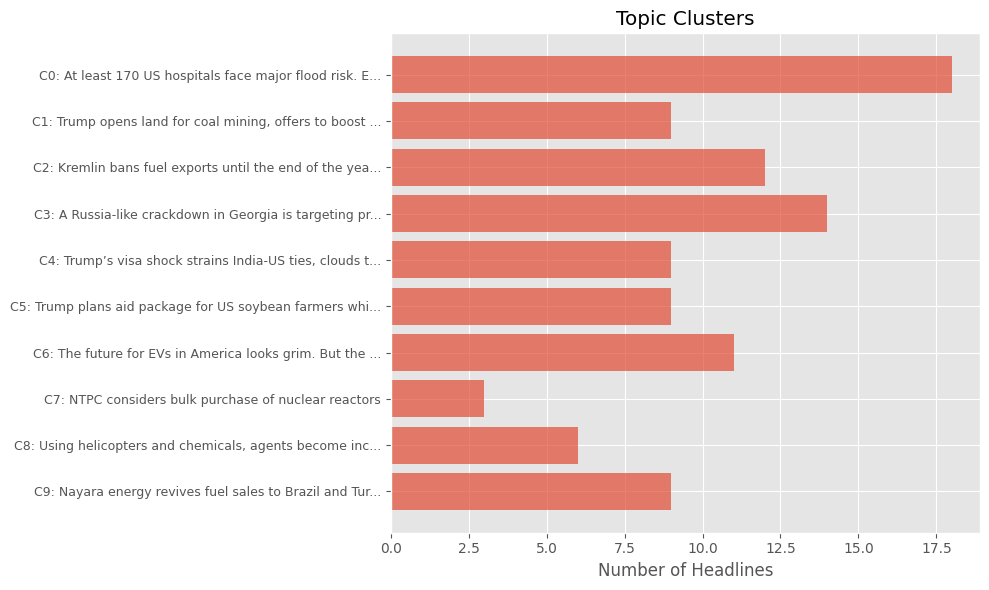

In [36]:
# Visualize topic clusters
fig, ax = plt.subplots(figsize=(10, 6))

# Get cluster sizes and representative headlines
cluster_sizes = []
cluster_topics = []

for cluster_id in range(optimal_n_clusters):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    cluster_embeddings = embeddings[cluster_indices]
    distances = np.linalg.norm(cluster_embeddings - cluster_centers[cluster_id], axis=1)
    closest_idx = cluster_indices[np.argmin(distances)]
    
    cluster_sizes.append(len(cluster_indices))
    # Truncate headline for display
    headline = headlines[closest_idx]
    cluster_topics.append(headline[:50] + '...' if len(headline) > 50 else headline)

# Create horizontal bar chart
y_pos = np.arange(len(cluster_topics))
ax.barh(y_pos, cluster_sizes, alpha=0.7)

# Labels
ax.set_yticks(y_pos)
ax.set_yticklabels([f"C{i}: {topic}" for i, topic in enumerate(cluster_topics)], fontsize=9)
ax.set_xlabel('Number of Headlines')
ax.set_title('Topic Clusters')
ax.invert_yaxis()

plt.tight_layout()
plt.show()


---
## NewsAPI.ai

Testing the NewsAPI.ai endpoint using the eventregistry package. This API provides more comprehensive article data and better search capabilities.


In [66]:
import requests
from datetime import datetime, timedelta

# Load environment variables from .env file in the same directory as notebook
load_dotenv('.env')

# Get and verify API key
api_key_ai = os.getenv('NEWSAPIAI_KEY')
if not api_key_ai:
    raise ValueError("NEWSAPIAI_KEY not found in environment variables. Please check your .env file.")

print(f"API key loaded: {'Yes' if api_key_ai else 'No'}")
print(f"API key length: {len(api_key_ai) if api_key_ai else 0} characters")

print("\n=== Fetching Articles from NewsAPI.ai ===")
print(f"Search period: Last 30 days")
print(f"Keywords: electricity, oil, gas, coal")

# NewsAPI.ai endpoint
url = "https://eventregistry.org/api/v1/article/getArticles"

# Search parameters (as JSON body for POST request - following their example)
params = {
    "action": "getArticles",
    "keyword": "electricity OR oil OR gas OR coal",
    "articlesPage": 1,
    "articlesCount": 100,
    "articlesSortBy": "date",
    "articlesSortByAsc": False,
    "dataType": ["news"],
    "forceMaxDataTimeWindow": 31,
    "resultType": "articles",
    "apiKey": api_key_ai
}

print("Request parameters:", params)

# Make the request
try:
    response = requests.post(url, json=params)
    response.raise_for_status()
    
    data = response.json()
    print(f"Response status: {response.status_code}")
    print(f"Full response keys: {list(data.keys())}")
    
    if "articles" in data:
        articles_data = data["articles"]
        print(f"Articles data keys: {list(articles_data.keys())}")
        
        if "results" in articles_data:
            articles_ai = articles_data["results"]
            print(f"Number of articles returned: {len(articles_ai)}")
            
            if len(articles_ai) > 0:
                # Convert to DataFrame
                df_articles_ai = pd.DataFrame(articles_ai)
                print(f"DataFrame shape: {df_articles_ai.shape}")
                print(f"\nColumns available: {df_articles_ai.columns.tolist()}")
            else:
                print("No articles in results array")
                # Check if there are other fields that might contain articles
                for key, value in articles_data.items():
                    if isinstance(value, list) and len(value) > 0:
                        print(f"Found {len(value)} items in '{key}' field")
        else:
            print("No 'results' field in articles data")
    else:
        print("No 'articles' field in response")
        if "error" in data:
            print(f"Error: {data['error']}")
        else:
            print("Full response:", data)
        
except requests.exceptions.RequestException as e:
    print(f"Request error: {e}")
    if hasattr(e, 'response') and e.response is not None:
        print(f"Response status: {e.response.status_code}")
        print(f"Response text: {e.response.text}")
except Exception as e:
    print(f"Error: {e}")
    raise


API key loaded: Yes
API key length: 36 characters

=== Fetching Articles from NewsAPI.ai ===
Search period: Last 30 days
Keywords: electricity, oil, gas, coal
Request parameters: {'action': 'getArticles', 'keyword': 'electricity OR oil OR gas OR coal', 'articlesPage': 1, 'articlesCount': 100, 'articlesSortBy': 'date', 'articlesSortByAsc': False, 'dataType': ['news'], 'forceMaxDataTimeWindow': 31, 'resultType': 'articles', 'apiKey': 'ed8cdbb5-50ac-4018-94c5-a73eb4c85319'}
Response status: 200
Full response keys: ['articles', 'info']
Articles data keys: ['results', 'totalResults', 'page', 'count', 'pages']
Number of articles returned: 0
No articles in results array


In [59]:
# Extract source and date information
if 'source' in df_articles_ai.columns:
    # Source column might be a dict or object
    if isinstance(df_articles_ai['source'].iloc[0], dict):
        df_articles_ai['source_name'] = df_articles_ai['source'].apply(lambda x: x.get('title', x.get('name', 'Unknown')) if isinstance(x, dict) else str(x))
    else:
        df_articles_ai['source_name'] = df_articles_ai['source'].astype(str)

# Parse date
if 'date' in df_articles_ai.columns:
    df_articles_ai['date_parsed'] = pd.to_datetime(df_articles_ai['date'])
elif 'dateTime' in df_articles_ai.columns:
    df_articles_ai['date_parsed'] = pd.to_datetime(df_articles_ai['dateTime'])
elif 'publishedAt' in df_articles_ai.columns:
    df_articles_ai['date_parsed'] = pd.to_datetime(df_articles_ai['publishedAt'])

print("Data preprocessing complete!")
print(f"\nSample article titles:")
title_col = 'title' if 'title' in df_articles_ai.columns else df_articles_ai.columns[0]
for i, title in enumerate(df_articles_ai[title_col].head(3), 1):
    print(f"{i}. {title}")


Data preprocessing complete!

Sample article titles:
1. Myanmar's military strikes village in glider raid, killing at least 24 people including children
2. Gold climbs above $4,000 in a record move - what is behind the rally?
3. Mandela's grandson returns to South Africa after deportation by Israel


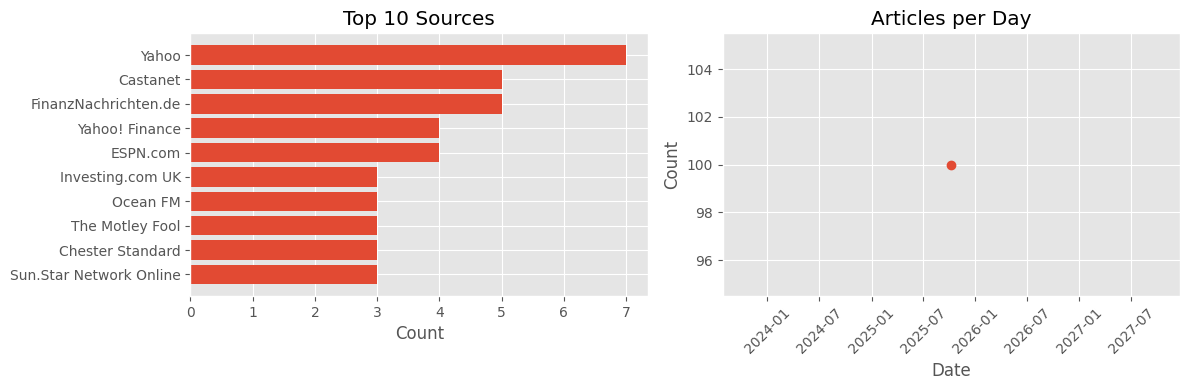


Total unique sources: 58
Date range: 2025-10-08 to 2025-10-08


In [60]:
# Visualize source and date distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Distribution of sources (top 10)
if 'source_name' in df_articles_ai.columns:
    source_counts = df_articles_ai['source_name'].value_counts().head(10)
    axes[0].barh(range(len(source_counts)), source_counts.values)
    axes[0].set_yticks(range(len(source_counts)))
    axes[0].set_yticklabels(source_counts.index)
    axes[0].set_xlabel('Count')
    axes[0].set_title('Top 10 Sources')
    axes[0].invert_yaxis()
else:
    axes[0].text(0.5, 0.5, 'Source data not available', ha='center', va='center')
    axes[0].set_title('Sources')

# Plot 2: Articles per day
if 'date_parsed' in df_articles_ai.columns:
    df_articles_ai['date_only'] = df_articles_ai['date_parsed'].dt.date
    articles_per_day = df_articles_ai.groupby('date_only').size().sort_index()
    axes[1].plot(articles_per_day.index, articles_per_day.values, marker='o', linewidth=1.5)
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Articles per Day')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'Date data not available', ha='center', va='center')
    axes[1].set_title('Articles per Day')

plt.tight_layout()
plt.show()

print(f"\nTotal unique sources: {df_articles_ai['source_name'].nunique() if 'source_name' in df_articles_ai.columns else 'N/A'}")
print(f"Date range: {df_articles_ai['date_only'].min() if 'date_only' in df_articles_ai.columns else 'N/A'} to {df_articles_ai['date_only'].max() if 'date_only' in df_articles_ai.columns else 'N/A'}")


---
# NewsAPI AI
Now doing the same with newsapi.ai